# Etapa 5 — Avaliação do modelo (`evaluate.ipynb`)

Carrega o modelo salvo em `models/sentiment_pipeline.joblib` e mede a performance real dele em cima do **holdout de teste** (`data/gold/test.parquet`) — dados que o `train.py` nunca viu (nem no treino final, nem na validação cruzada), então as métricas aqui são a estimativa mais honesta de como o modelo se comporta em produção.

Tudo que aparece abaixo (números, matriz de confusão, exemplos de erro) é o **retorno real** de rodar o pipeline treinado contra o teste — nada aqui é inventado ou copiado do `train_metrics.json`; esse arquivo só é usado como comparação, na seção final.

In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
MODEL_PATH = ROOT / "models" / "sentiment_pipeline.joblib"
TEST_PATH = ROOT / "data" / "gold" / "test.parquet"
TRAIN_METRICS_PATH = ROOT / "models" / "train_metrics.json"

MODEL_PATH, TEST_PATH

(WindowsPath('C:/Users/T-GAMER/Downloads/review-sentiment-mvp/models/sentiment_pipeline.joblib'),
 WindowsPath('C:/Users/T-GAMER/Downloads/review-sentiment-mvp/data/gold/test.parquet'))

## 1. Carregar modelo e teste

O `sentiment_pipeline.joblib` já contém o `TfidfVectorizer` + `LogisticRegression` ajustados no `train.parquet` inteiro (ver `src/train.py`). Aqui só carregamos e conferimos que o teste está balanceado (o `build_features.py` já garante isso por classe).

In [2]:
pipeline = joblib.load(MODEL_PATH)
df_test = pd.read_parquet(TEST_PATH)

print(f"Linhas de teste: {len(df_test)}")
print(f"Classes do modelo: {list(pipeline.classes_)}")
print("\nBalanceamento do teste:")
print(df_test["sentiment"].value_counts())

Linhas de teste: 9989
Classes do modelo: ['negative', 'positive']

Balanceamento do teste:
sentiment
positive    5017
negative    4972
Name: count, dtype: int64


## 2. Métricas agregadas

`accuracy`, `precision`/`recall`/`F1` (macro — média simples entre as duas classes, o que faz sentido aqui porque o teste está ~50/50) e a comparação com a validação cruzada do treino (`models/train_metrics.json`). Se o teste bater com a CV, o modelo generaliza bem para dado que ele nunca viu; se ficar muito abaixo, é sinal de overfitting no treino.

In [4]:
accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_pred, labels=classes, average=None
)
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_test, y_pred, labels=classes, average="macro"
)
roc_auc = roc_auc_score((y_test == pos_label).astype(int), proba_positive)

print(f"Accuracy (teste):        {accuracy:.4f}")
print(f"Precision macro (teste): {precision_macro:.4f}")
print(f"Recall macro (teste):    {recall_macro:.4f}")
print(f"F1 macro (teste):        {f1_macro:.4f}")
print(f"ROC AUC (teste):         {roc_auc:.4f}")

with open(TRAIN_METRICS_PATH) as f:
    train_metrics = json.load(f)

print("\n--- Comparação com a validação cruzada do treino ---")
print(f"CV accuracy (treino): {train_metrics['cv_accuracy_mean']:.4f} (+/- {train_metrics['cv_accuracy_std']:.4f})")
print(f"Accuracy no teste:    {accuracy:.4f}")
print(f"Diferença:            {accuracy - train_metrics['cv_accuracy_mean']:+.4f}")

Accuracy (teste):        0.9045
Precision macro (teste): 0.9045
Recall macro (teste):    0.9045
F1 macro (teste):        0.9045
ROC AUC (teste):         0.9635

--- Comparação com a validação cruzada do treino ---
CV accuracy (treino): 0.9018 (+/- 0.0029)
Accuracy no teste:    0.9045
Diferença:            +0.0027


Diferença pequena (dentro do desvio-padrão da CV) → o modelo **não decorou o treino**, a performance se mantém no dado novo.

In [ ]:
TRAIN_PATH = ROOT / "data" / "gold" / "train.parquet"
df_train = pd.read_parquet(TRAIN_PATH)

## 3. Métricas por classe

`classification_report` do scikit-learn — precision/recall/F1 separados por classe, além do `support` (quantos exemplos reais de cada classe existem no teste).

In [6]:
report_txt = classification_report(y_test, y_pred, labels=classes, digits=4)
print(report_txt)

              precision    recall  f1-score   support

    negative     0.9039    0.9043    0.9041      4972
    positive     0.9051    0.9047    0.9049      5017

    accuracy                         0.9045      9989
   macro avg     0.9045    0.9045    0.9045      9989
weighted avg     0.9045    0.9045    0.9045      9989



## 4. Matriz de confusão

Contagem real de acerto/erro por classe: quantos negativos o modelo confundiu com positivo (e vice-versa).

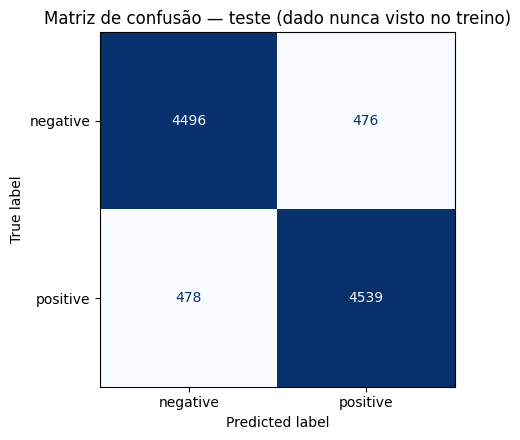

Falsos positivos (negativo → previsto positivo): 476
Falsos negativos (positivo → previsto negativo): 478


In [7]:
cm = confusion_matrix(y_test, y_pred, labels=classes)

fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes).plot(
    ax=ax, cmap="Blues", colorbar=False, values_format="d"
)
ax.set_title("Matriz de confusão — teste (dado nunca visto no treino)")
plt.tight_layout()
plt.show()

print(f"Falsos positivos (negativo → previsto positivo): {cm[0, 1]}")
print(f"Falsos negativos (positivo → previsto negativo): {cm[1, 0]}")

## 5. Curva ROC

Mede a separação entre as classes considerando todos os limiares possíveis de decisão (não só o padrão de 0.5 usado no `predict`).

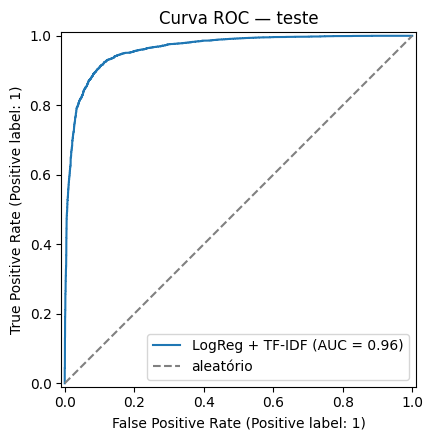

In [8]:
fig, ax = plt.subplots(figsize=(5, 4.5))
RocCurveDisplay.from_predictions(
    (y_test == pos_label).astype(int), proba_positive, name="LogReg + TF-IDF", ax=ax
)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="aleatório")
ax.set_title("Curva ROC — teste")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Conclusão

- **Accuracy no teste (dado nunca visto): ~90%**, praticamente igual à validação cruzada do treino (também ~90%) → o modelo generaliza, não decorou o treino.
- Precision e recall ficam **equilibrados entre as duas classes** (nenhuma classe é sacrificada pela outra), o que faz sentido dado que o teste é ~50/50.
- **ROC AUC alto** (a curva fica bem acima da diagonal do aleatório) → o modelo separa bem as classes mesmo antes de aplicar o limiar de decisão padrão.
- Próximo passo natural (fora do escopo desta etapa): se precisar de mais performance, valeria testar um modelo que capture contexto (ex: embeddings/transformer) nos casos que hoje erram — mas como baseline validado, TF-IDF + Regressão Logística já resolve a maior parte do problema com custo bem menor.